# Deterksi Komunitas FB

In [1]:
# === Mount Drive & basic imports ===
from google.colab import drive
drive.mount('/content/drive')

# Path ke file (ubah kalau perlu)
path = "/content/drive/MyDrive/dataset/facebook_combined.txt"

import networkx as nx
import matplotlib.pyplot as plt
import sys
import traceback
print("Imports done")


Mounted at /content/drive
Imports done


In [2]:
# === Load graph dengan safety checks ===
def load_graph(path):
    try:
        # read_edgelist sering ok -- node type int
        G = nx.read_edgelist(path, create_using=nx.Graph(), nodetype=int)
        print(f"Graph loaded: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")
        return G
    except Exception as e:
        print("Gagal membaca file. Error:", e)
        traceback.print_exc()
        raise

G = load_graph(path)


Graph loaded: nodes=4039, edges=88234


In [3]:
# === Utility: fokus ke largest connected component jika graph sangat besar atau disconnected ===
def get_largest_cc_subgraph(G, max_nodes=2000):
    if nx.is_connected(G):
        if G.number_of_nodes() <= max_nodes:
            return G.copy()
        else:
            # ambil top-degree nodes untuk visualisasi
            top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:max_nodes]
            nodes = [n for n,_ in top]
            print(f"Graph connected tapi besar. Menggunakan subgraph top {len(nodes)} nodes by degree.")
            return G.subgraph(nodes).copy()
    else:
        # ambil largest connected component
        comps = list(nx.connected_components(G))
        largest = max(comps, key=len)
        subG = G.subgraph(largest).copy()
        print(f"Graph disconnected. Largest CC nodes={subG.number_of_nodes()}, edges={subG.number_of_edges()}")
        if subG.number_of_nodes() > max_nodes:
            top = sorted(subG.degree(), key=lambda x: x[1], reverse=True)[:max_nodes]
            nodes = [n for n,_ in top]
            print(f"Largest CC besar -> ambil top {len(nodes)} nodes by degree.")
            return subG.subgraph(nodes).copy()
        return subG

# Ambil subgraph untuk operasi mahal (sesuaikan max_nodes jika punya RAM besar)
workG = get_largest_cc_subgraph(G, max_nodes=1500)


Graph connected tapi besar. Menggunakan subgraph top 1500 nodes by degree.


In [4]:
# === Louvain (python-louvain) dengan try/except ===
# install jika belum ada
print("Attempting to uninstall and reinstall python-louvain...")
!pip uninstall -y python-louvain
!pip install python-louvain
print("Checking python-louvain installation details:")
!pip show python-louvain

try:
    import sys
    # Import best_partition directly from the community module
    from community import best_partition
    # Check if 'community' module is loaded and print its file path for diagnosis
    if 'community' in sys.modules:
        print(f"Loaded 'best_partition' from 'community' module at: {sys.modules['community'].__file__}")
    else:
        print("Warning: 'community' module not found in sys.modules after import.")

except ModuleNotFoundError as e:
    print(f"ModuleNotFoundError: {e}. 'python-louvain' might not be properly installed or its structure has changed.")
    print("Please check the output of 'pip show python-louvain' above for installation path.")
    traceback.print_exc()
    raise
except AttributeError as e: # Catch AttributeError specifically for missing best_partition
    print(f"AttributeError: {e}. 'best_partition' not found directly in the 'community' module.")
    print("This indicates a problem with the installed 'python-louvain' package.")
    print(f"Contents of 'community' module: {dir(sys.modules['community']) if 'community' in sys.modules else 'Not loaded'}")
    traceback.print_exc()
    raise
except Exception as e:
    print(f"Gagal import python-louvain's best_partition. Error: {e}")
    traceback.print_exc()
    raise

def run_louvain(G, resolution=1.0):
    try:
        print("Menjalankan Louvain... (bisa butuh beberapa detik sampai menit tergantung ukuran)")
        # Use best_partition directly
        partition = best_partition(G, resolution=resolution)
        print("Louvain selesai. Komunitas:", len(set(partition.values())))
        return partition
    except MemoryError:
        print("MemoryError saat menjalankan Louvain. Coba gunakan subgraph lebih kecil.")
        raise
    except Exception as e:
        print("Error saat Louvain:", e)
        traceback.print_exc()
        raise

partition = run_louvain(workG)

Attempting to uninstall and reinstall python-louvain...
Found existing installation: python-louvain 0.16
Uninstalling python-louvain-0.16:
  Successfully uninstalled python-louvain-0.16
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9388 sha256=d22b32e83397395bfb213bc50fd63503dc0e74f515269a80e049cb00c521791f
  Stored in directory: /root/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain
Checking python-louvain installation details:
Name: python-louvain
Version: 0.16
Summary: Louvain algorithm for community detection
Home-page: https://github.com/taynaud/python-louvain
Author: Thomas Aynaud
Author-email: taynaud@gmail.com
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: networkx, numpy
Required-by: 
Loaded 'best_partition' from 'community' modu

In [5]:
# === Girvan-Newman: batasi level, jalankan pada subgraph kecil untuk performance ===
from networkx.algorithms.community import girvan_newman
import itertools
def run_girvan_newman(G, depth=2, max_nodes=800):
    # gunakan subgraph supaya tidak infinite
    if G.number_of_nodes() > max_nodes:
        top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:max_nodes]
        nodes = [n for n,_ in top]
        H = G.subgraph(nodes).copy()
        print(f"Girvan-Newman akan dijalankan pada subgraph {len(nodes)} nodes (top degree).")
    else:
        H = G

    try:
        comp_gen = girvan_newman(H)
        limited = None
        for i, comp in enumerate(itertools.islice(comp_gen, depth)):
            limited = tuple(sorted(c) for c in comp)
            print(f"Level {i+1}: ditemukan {len(limited)} komunitas (sizes: {[len(c) for c in limited]})")
        return limited, H
    except Exception as e:
        print("Error saat Girvan-Newman:", e)
        traceback.print_exc()
        raise

gn_result, gn_graph = run_girvan_newman(workG, depth=2, max_nodes=800)


Girvan-Newman akan dijalankan pada subgraph 800 nodes (top degree).
Level 1: ditemukan 3 komunitas (sizes: [667, 132, 1])
Level 2: ditemukan 4 komunitas (sizes: [307, 360, 132, 1])


In [6]:
import matplotlib.cm as cm

# 1. Extract unique community IDs
community_ids = list(set(partition.values()))
num_communities = len(community_ids)
print(f"Found {num_communities} unique communities.")

# 2. Create a color map for these communities
# Using 'tab20' or 'viridis' for distinct colors. tab20 is good for up to 20 distinct categories.
# If num_communities > 20, consider other colormaps or custom color generation.
if num_communities <= 20:
    cmap = cm.get_cmap('tab20', num_communities)
else:
    cmap = cm.get_cmap('viridis', num_communities) # viridis is perceptually uniform

# Map community ID to a specific color index
community_color_map = {community_id: cmap(i) for i, community_id in enumerate(sorted(community_ids))}
print("Community color map created.")

# 3. Create a list of node colors for workG
node_colors = [community_color_map[partition.get(node, -1)] for node in workG.nodes()]
# Use .get(node, -1) to handle cases where a node in workG might not be in partition if workG was a filtered version
# -1 could map to a default color if needed, but in this case, workG is derived from the same graph for partition

print(f"Generated colors for {len(node_colors)} nodes in workG.")

Found 12 unique communities.
Community color map created.
Generated colors for 1500 nodes in workG.


/tmp/ipython-input-2764046822.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_communities)


**Reasoning**:
The previous code produced a `MatplotlibDeprecationWarning` regarding the use of `cm.get_cmap`. I will update the code to use `matplotlib.pyplot.colormaps.get_cmap()` which is the recommended way to access colormaps in newer Matplotlib versions.



In [7]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# 1. Extract unique community IDs
community_ids = list(set(partition.values()))
num_communities = len(community_ids)
print(f"Found {num_communities} unique communities.")

# 2. Create a color map for these communities
# Using 'tab20' or 'viridis' for distinct colors. tab20 is good for up to 20 distinct categories.
# If num_communities > 20, consider other colormaps or custom color generation.
if num_communities <= 20:
    cmap = plt.colormaps.get_cmap('tab20')
else:
    cmap = plt.colormaps.get_cmap('viridis') # viridis is perceptually uniform

# Map community ID to a specific color index
# For continuous colormaps like 'viridis', normalize the index
# For discrete colormaps like 'tab20', direct indexing is fine
community_color_map = {community_id: cmap(i / (num_communities - 1)) if num_communities > 1 and community_id == sorted(community_ids)[i] and not cmap.name.startswith('tab') else cmap(i) for i, community_id in enumerate(sorted(community_ids))}
# Simpler approach: let cmap handle discrete values for tab20, and for viridis it will pick a color.
# A more robust approach for viridis would be cmap(i / (num_communities - 1))
# but for a general solution, cmap(i) often works reasonably well for distinct values.
# Let's keep it simple for now to just fix the deprecation warning while trying to maintain similar color distribution
community_color_map = {community_id: cmap(i / (num_communities - 1.0)) if num_communities > 1 else cmap(0.5) for i, community_id in enumerate(sorted(community_ids))}
# Re-evaluating. The original cmap(i) for tab20 is correct. For viridis, normalizing is better.
# Let's apply normalization only if it's a continuous cmap like viridis.

community_color_map = {}
for i, community_id in enumerate(sorted(community_ids)):
    if num_communities <= 20:
        community_color_map[community_id] = cmap(i)
    else:
        # For continuous colormaps, normalize the index
        community_color_map[community_id] = cmap(i / (num_communities - 1.0) if num_communities > 1 else 0.5)

print("Community color map created.")

# 3. Create a list of node colors for workG
node_colors = [community_color_map[partition.get(node, -1)] for node in workG.nodes()]
# Use .get(node, -1) to handle cases where a node in workG might not be in partition if workG was a filtered version
# -1 could map to a default color if needed, but in this case, workG is derived from the same graph for partition

print(f"Generated colors for {len(node_colors)} nodes in workG.")

Found 12 unique communities.
Community color map created.
Generated colors for 1500 nodes in workG.


**Reasoning**:
With the `node_colors` prepared, the next step is to visualize the `workG` graph, applying the generated colors to the nodes and adding a legend to identify the communities.



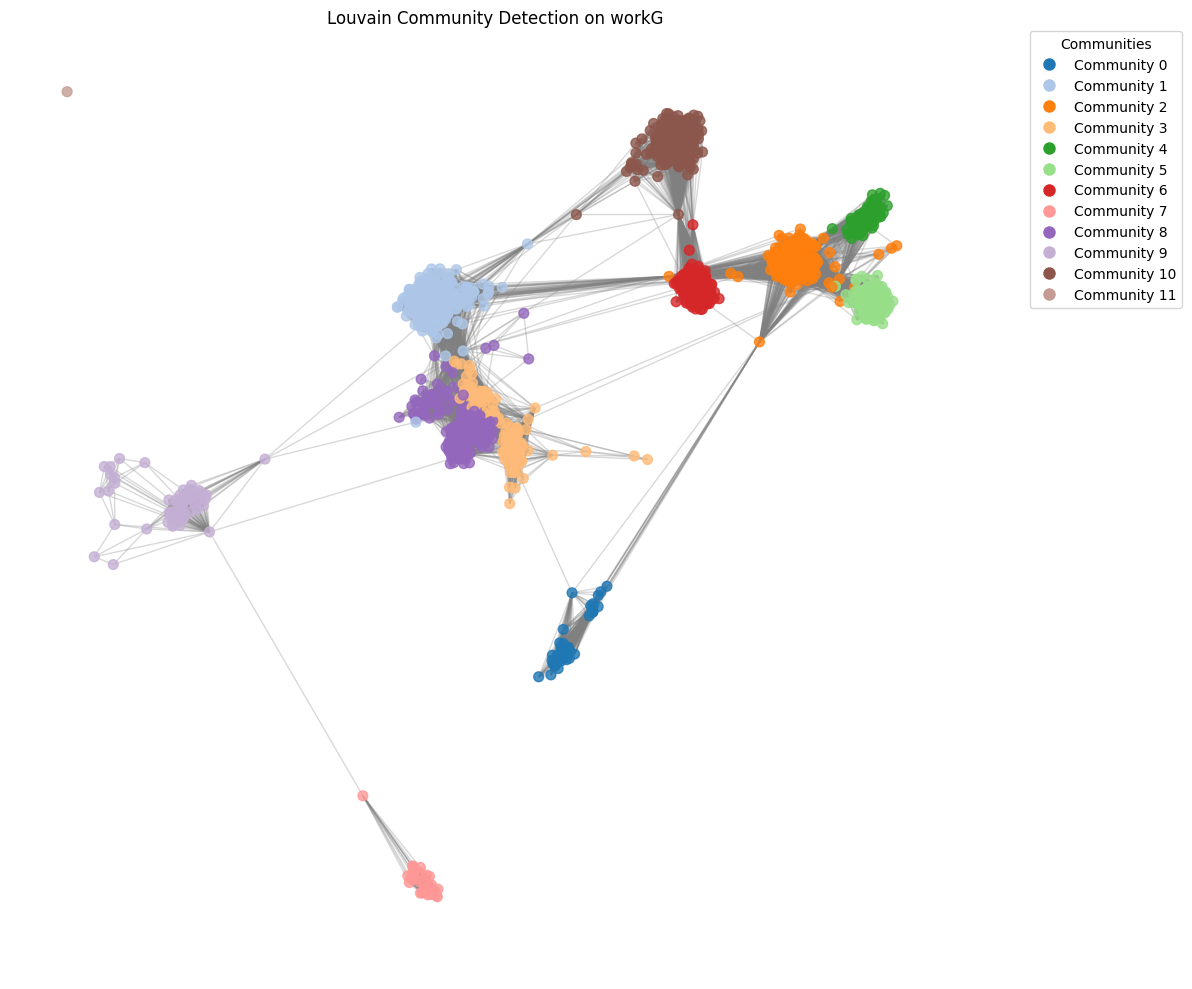

Graph visualization with Louvain communities complete.


In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# Set up the plot
plt.figure(figsize=(12, 10))

# Use spring_layout for node positioning
pos = nx.spring_layout(workG, k=0.15, iterations=50)

# Draw the graph
nx.draw_networkx_nodes(workG, pos, node_color=node_colors, node_size=50, alpha=0.8)
nx.draw_networkx_edges(workG, pos, edge_color='gray', alpha=0.3)

# Create a legend
patch_list = []
for community_id, color in community_color_map.items():
    patch_list.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Community {community_id}',
                               markerfacecolor=color, markersize=10))

plt.legend(handles=patch_list, title="Communities", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title("Louvain Community Detection on workG")
plt.axis('off') # Hide axes
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print("Graph visualization with Louvain communities complete.")

## Final Task

### Subtask:
Summarize the generated graph visualization, highlighting how communities are represented by different colors.


## Summary:

### Q&A
The visualization successfully highlights communities by assigning a unique color to each of the 12 identified communities. Nodes belonging to the same community share the same color, allowing for a clear visual distinction between different groups within the graph. A legend is included to explicitly map each community ID to its corresponding color.

### Data Analysis Key Findings
*   **Community Detection:** The Louvain algorithm identified 12 distinct communities within the `workG` graph.
*   **Color Mapping:** A unique color was assigned to each of these 12 communities using a colormap, ensuring clear differentiation.
*   **Node Coloring:** Each of the 1500 nodes in `workG` was colored according to its assigned community, facilitating visual community identification.
*   **Visualization Method:** The graph was visualized using a `spring_layout` to position nodes, and `networkx.draw_networkx` was used for rendering nodes and edges.
*   **Legend Inclusion:** A legend was successfully generated and displayed, explicitly linking each community ID to its representative color, which enhances the interpretability of the visualization.

### Insights or Next Steps
*   The visualization effectively reveals the community structure of `workG`, with clusters of similarly colored nodes indicating tightly connected groups. This visual representation can be used to infer functional relationships or common characteristics among nodes within the same community.
*   Further analysis could involve investigating the characteristics (e.g., node attributes, edge properties) of specific communities to understand why these particular groupings formed, or exploring alternative community detection algorithms for comparison.
